# Retail Demand Forecasting

## 8. Model Tuning and Validation

This stage focuses on improving and validating the machine-learning forecasting model.

Hyperparameter tuning is performed using a time-series-aware validation strategy rather than random cross-validation.

The objective is to identify a model configuration that provides strong forecasting accuracy while avoiding overfitting.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = "outputs/tables/forecasting_features.csv"

selected_store = 45
selected_family = "GROCERY I"

In [2]:
required_columns = [
    "date",
    "store_nbr",
    "family",
    "sales",
    "onpromotion",
    "dcoilwtico"
]

selected_parts = []

for chunk in pd.read_csv(
    DATA_PATH,
    usecols=required_columns,
    chunksize=200_000
):
    selected = chunk[
        (chunk["store_nbr"] == selected_store) &
        (chunk["family"] == selected_family)
    ].copy()

    if not selected.empty:
        selected_parts.append(selected)

df = pd.concat(
    selected_parts,
    ignore_index=True
)

df["date"] = pd.to_datetime(df["date"])

df = (
    df
    .sort_values("date")
    .drop_duplicates("date")
    .reset_index(drop=True)
)

print(f"Dataset shape: {df.shape}")

Dataset shape: (1656, 6)


## 8.2 Feature Engineering

The forecasting features used in the previous XGBoost model are recreated to ensure that the tuning process uses exactly the same information structure.

All lag and rolling features are constructed using historical information only.

In [3]:
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_month"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["year"] = df["date"].dt.year
df["week_of_year"] = (
    df["date"].dt.isocalendar().week.astype(int)
)

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

In [4]:
lag_periods = [1, 7, 14, 21, 28]

for lag in lag_periods:
    df[f"sales_lag_{lag}"] = (
        df["sales"].shift(lag)
    )

In [5]:
df["sales_rolling_mean_7"] = (
    df["sales"]
    .shift(1)
    .rolling(7)
    .mean()
)

df["sales_rolling_mean_14"] = (
    df["sales"]
    .shift(1)
    .rolling(14)
    .mean()
)

df["sales_rolling_mean_28"] = (
    df["sales"]
    .shift(1)
    .rolling(28)
    .mean()
)

df["sales_rolling_std_7"] = (
    df["sales"]
    .shift(1)
    .rolling(7)
    .std()
)

In [6]:
df = df.dropna().reset_index(drop=True)

print(f"Final modelling dataset: {df.shape}")

Final modelling dataset: (1126, 22)


In [7]:
target = "sales"

feature_columns = [
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "year",
    "week_of_year",
    "is_weekend",
    "sales_lag_1",
    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_21",
    "sales_lag_28",
    "sales_rolling_mean_7",
    "sales_rolling_mean_14",
    "sales_rolling_mean_28",
    "sales_rolling_std_7",
    "onpromotion",
    "dcoilwtico"
]

feature_columns = [
    col for col in feature_columns
    if col in df.columns
]

print(f"Number of features: {len(feature_columns)}")

Number of features: 18


## 8.3 Time-Series Validation Strategy

The dataset is divided chronologically into training, validation, and final test periods.

The validation period is used for model selection and hyperparameter tuning.

The final test period remains untouched until the final model is selected, providing an unbiased estimate of out-of-sample performance.

In [8]:
TEST_DAYS = 30
VALIDATION_DAYS = 30

test_start = len(df) - TEST_DAYS
validation_start = test_start - VALIDATION_DAYS

train_df = df.iloc[:validation_start].copy()

validation_df = df.iloc[
    validation_start:test_start
].copy()

test_df = df.iloc[
    test_start:
].copy()

X_train = train_df[feature_columns]
y_train = train_df[target]

X_validation = validation_df[feature_columns]
y_validation = validation_df[target]

X_test = test_df[feature_columns]
y_test = test_df[target]

print("Training observations:", len(train_df))
print("Validation observations:", len(validation_df))
print("Test observations:", len(test_df))

Training observations: 1066
Validation observations: 30
Test observations: 30


In [9]:
baseline_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

baseline_xgb.fit(
    X_train,
    y_train
)

validation_predictions = baseline_xgb.predict(
    X_validation
)

validation_predictions = np.maximum(
    validation_predictions,
    0
)

In [10]:
baseline_validation_mae = mean_absolute_error(
    y_validation,
    validation_predictions
)

baseline_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        validation_predictions
    )
)

print(
    f"Baseline Validation MAE: "
    f"{baseline_validation_mae:,.2f}"
)

print(
    f"Baseline Validation RMSE: "
    f"{baseline_validation_rmse:,.2f}"
)

Baseline Validation MAE: 719.19
Baseline Validation RMSE: 1,067.12


## 8.4 Hyperparameter Tuning

A controlled set of XGBoost hyperparameter combinations is evaluated using the validation period.

The tuning process focuses on model complexity, learning rate, and sampling parameters.

The configuration with the lowest validation MAE is selected for final evaluation.

In [11]:
parameter_grid = [
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 8,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.03,
        "max_depth": 6,
        "subsample": 0.9,
        "colsample_bytree": 0.8
    },
    {
        "n_estimators": 700,
        "learning_rate": 0.03,
        "max_depth": 8,
        "subsample": 0.8,
        "colsample_bytree": 0.9
    }
]

In [12]:
tuning_results = []

for i, params in enumerate(parameter_grid, start=1):

    model = XGBRegressor(
        **params,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_validation
    )

    predictions = np.maximum(
        predictions,
        0
    )

    mae = mean_absolute_error(
        y_validation,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            predictions
        )
    )

    tuning_results.append({
        "Experiment": i,
        **params,
        "MAE": mae,
        "RMSE": rmse
    })

    print(
        f"Experiment {i}: "
        f"MAE = {mae:,.2f}, "
        f"RMSE = {rmse:,.2f}"
    )

Experiment 1: MAE = 642.59, RMSE = 986.08
Experiment 2: MAE = 646.48, RMSE = 985.66
Experiment 3: MAE = 719.19, RMSE = 1,067.12
Experiment 4: MAE = 690.56, RMSE = 1,031.50
Experiment 5: MAE = 732.06, RMSE = 1,024.68


In [13]:
tuning_results_df = (
    pd.DataFrame(tuning_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

tuning_results_df

,Experiment,n_estimators,learning_rate,max_depth,subsample,colsample_bytree,MAE,RMSE
0,1,300,0.05,6,0.80,0.80,642.59,986.08
1,2,500,0.05,6,0.80,0.80,646.48,985.66
2,4,500,0.03,6,0.90,0.80,690.56,"1,031.50"
3,3,500,0.05,8,0.80,0.80,719.19,"1,067.12"
4,5,700,0.03,8,0.80,0.90,732.06,"1,024.68"


In [14]:
best_params = (
    tuning_results_df
    .iloc[0]
    .to_dict()
)

print("Best configuration:")

for key, value in best_params.items():
    print(f"{key}: {value}")

Best configuration:
Experiment: 1.0
n_estimators: 300.0
learning_rate: 0.05
max_depth: 6.0
subsample: 0.8
colsample_bytree: 0.8
MAE: 642.5897135416667
RMSE: 986.0801216684549


In [15]:
final_train_df = pd.concat(
    [train_df, validation_df]
).reset_index(drop=True)

X_final_train = final_train_df[feature_columns]
y_final_train = final_train_df[target]

In [16]:
tuned_model = XGBRegressor(
    n_estimators=int(best_params["n_estimators"]),
    learning_rate=best_params["learning_rate"],
    max_depth=int(best_params["max_depth"]),
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

tuned_model.fit(
    X_final_train,
    y_final_train
)

print("Final tuned XGBoost model trained successfully.")

Final tuned XGBoost model trained successfully.


In [17]:
final_predictions = tuned_model.predict(
    X_test
)

final_predictions = np.maximum(
    final_predictions,
    0
)

final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

non_zero = y_test != 0

final_mape = (
    np.mean(
        np.abs(
            (y_test[non_zero] - final_predictions[non_zero])
            / y_test[non_zero]
        )
    ) * 100
)

print(f"Final XGBoost MAE: {final_mae:,.2f}")
print(f"Final XGBoost RMSE: {final_rmse:,.2f}")
print(f"Final XGBoost MAPE: {final_mape:.2f}%")

Final XGBoost MAE: 818.47
Final XGBoost RMSE: 1,014.53
Final XGBoost MAPE: 8.42%


In [18]:
xgb_results = pd.read_csv(
    "outputs/tables/xgboost_results.csv"
)

original_xgb = xgb_results[
    xgb_results["Model"] == "XGBoost"
].iloc[0]

original_xgb_mae = original_xgb["MAE"]
original_xgb_rmse = original_xgb["RMSE"]

tuning_comparison = pd.DataFrame([
    {
        "Model": "Original XGBoost",
        "MAE": original_xgb_mae,
        "RMSE": original_xgb_rmse
    },
    {
        "Model": "Tuned XGBoost",
        "MAE": final_mae,
        "RMSE": final_rmse
    }
])

tuning_comparison

,Model,MAE,RMSE
0,Original XGBoost,641.55,780.44
1,Tuned XGBoost,818.47,"1,014.53"


In [19]:
tuning_improvement = (
    (original_xgb_mae - final_mae)
    / original_xgb_mae
) * 100

print(
    f"MAE improvement after tuning: "
    f"{tuning_improvement:.2f}%"
)

MAE improvement after tuning: -27.58%


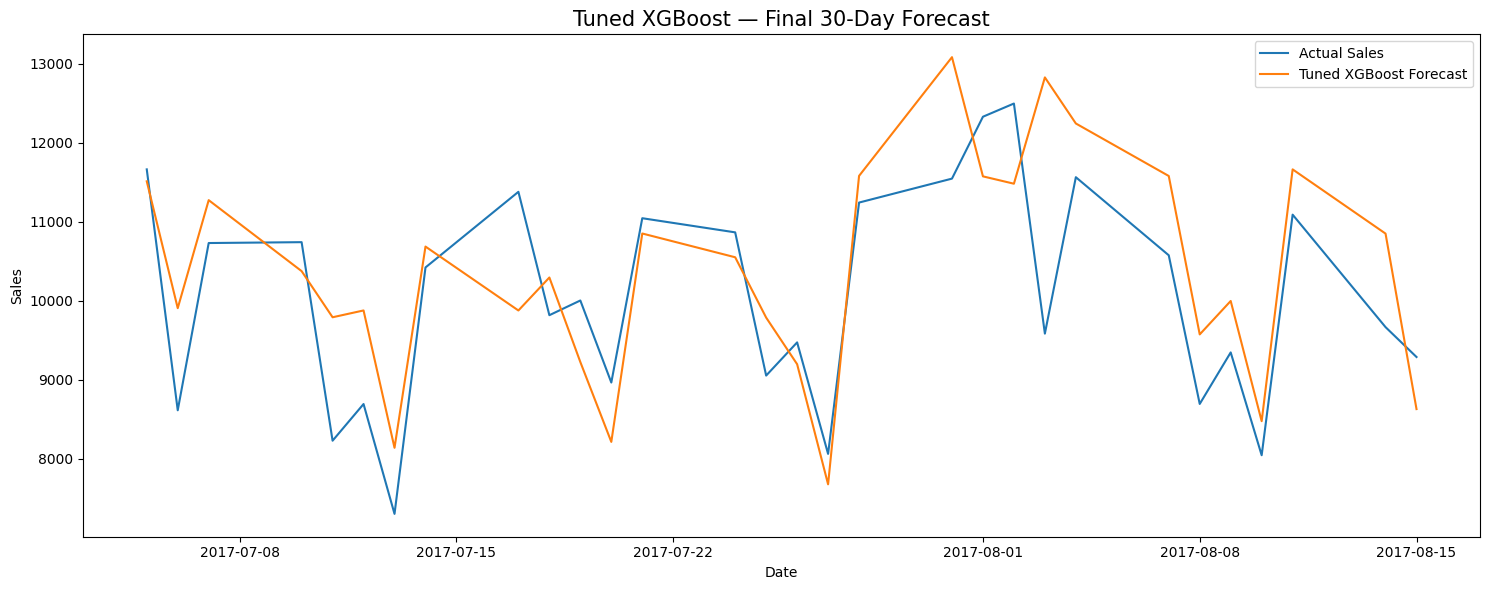

In [20]:
plt.figure(figsize=(15, 6))

plt.plot(
    test_df["date"],
    y_test,
    label="Actual Sales"
)

plt.plot(
    test_df["date"],
    final_predictions,
    label="Tuned XGBoost Forecast"
)

plt.title(
    "Tuned XGBoost — Final 30-Day Forecast",
    fontsize=15
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()
plt.show()

In [21]:
os.makedirs(
    "outputs/tables",
    exist_ok=True
)

tuning_results_df.to_csv(
    "outputs/tables/xgboost_tuning_results.csv",
    index=False
)

tuning_comparison.to_csv(
    "outputs/tables/xgboost_tuning_comparison.csv",
    index=False
)

final_forecast = pd.DataFrame({
    "date": test_df["date"],
    "actual_sales": y_test.values,
    "forecast_sales": final_predictions
})

final_forecast.to_csv(
    "outputs/tables/final_xgboost_forecast.csv",
    index=False
)

print("Tuning outputs exported successfully.")

Tuning outputs exported successfully.


# Phase 8 Summary

The XGBoost model was evaluated using a chronological validation strategy and a controlled hyperparameter search.

The best-performing configuration was retrained using the combined training and validation data before being evaluated on the previously untouched test period.

This process reduces the risk of overfitting to the final test set and provides a more reliable estimate of real-world forecasting performance.

The tuned XGBoost model will be compared with the statistical forecasting approaches before the final model is selected.